# 📓 Project 75 of 100: Google Trends & Data Visualization

## 🟡 Introduction

Google Trends gives us an estimate of how popular certain search terms are over time. But here’s the real question, parce:

Can search behavior tell us something about what’s happening in the real world?

In this project, I explore whether search volume relates to:

- The price of **Bitcoin**
- The stock price of **Tesla**
- The **unemployment rate** in the United States

I’ll work with time-series data, clean it properly, resample it to comparable intervals, and visualize it beautifully using Matplotlib.

By the end, I’ll not just plot lines — I’ll tell a story with data.

Data Sources: <br>
<ul>
<li> <a href="https://fred.stlouisfed.org/series/UNRATE/">Unemployment Rate from FRED</a></li>
<li> <a href="https://trends.google.com/trends/explore">Google Trends</a> </li>  
<li> <a href="https://finance.yahoo.com/quote/TSLA/history?p=TSLA">Yahoo Finance for Tesla Stock Price</a> </li>    
<li> <a href="https://finance.yahoo.com/quote/BTC-USD/history?p=BTC-USD">Yahoo Finance for Bitcoin Stock Price</a> </li>
</ul>

## 📦 Import Statements

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## 📂 Read the Data

Make sure all .csv files are in the same folder as your notebook.

In [2]:
df_tesla = pd.read_csv('TESLA Search Trend vs Price.csv')

df_btc_search = pd.read_csv('Bitcoin Search Trend.csv')
df_btc_price = pd.read_csv('Daily Bitcoin Price.csv')

df_unemployment = pd.read_csv('UE Benefits Search vs UE Rate 2004-19.csv')

## 🔍 Data Exploration

### 🚗 Tesla Data
#### Inspect the Data

In [3]:
print(df_tesla.shape)
df_tesla.head()

(124, 3)


,MONTH,TSLA_WEB_SEARCH,TSLA_USD_CLOSE
0,2010-06-01,3,4.766
1,2010-07-01,3,3.988
2,2010-08-01,2,3.896
3,2010-09-01,2,4.082
4,2010-10-01,2,4.368


#### Convert Dates

In [4]:
df_tesla['MONTH'] = pd.to_datetime(df_tesla['MONTH'])

#### Basic Info

In [5]:
df_tesla.info()

<class 'pandas.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   MONTH            124 non-null    datetime64[us]
 1   TSLA_WEB_SEARCH  124 non-null    int64         
 2   TSLA_USD_CLOSE   124 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 3.0 KB


### 🪙 Bitcoin Data
#### Inspect Search Data

In [6]:
df_btc_search.shape

(73, 2)

In [7]:
df_btc_search.head()

,MONTH,BTC_NEWS_SEARCH
0,2014-09,5
1,2014-10,4
2,2014-11,4
3,2014-12,4
4,2015-01,5


#### Inspect Price Data

In [8]:
df_btc_price.shape

(2204, 3)

In [9]:
df_btc_price.head()

,DATE,CLOSE,VOLUME
0,2014-09-17,457.334015,21056800.0
1,2014-09-18,424.440002,34483200.0
2,2014-09-19,394.795990,37919700.0
3,2014-09-20,408.903992,36863600.0
4,2014-09-21,398.821014,26580100.0


#### Convert Dates

In [10]:
df_btc_search['MONTH'] = pd.to_datetime(df_btc_search['MONTH'])
df_btc_price['DATE'] = pd.to_datetime(df_btc_price['DATE'])

### 📉 Unemployment Data

In [11]:
df_unemployment.shape

(181, 3)

In [12]:
df_unemployment.head()

,MONTH,UE_BENEFITS_WEB_SEARCH,UNRATE
0,2004-01,34,5.7
1,2004-02,33,5.6
2,2004-03,25,5.8
3,2004-04,29,5.6
4,2004-05,23,5.6


#### Convert Dates

In [13]:
df_unemployment['MONTH'] = pd.to_datetime(df_unemployment['MONTH'])

## 🧼 Checking for Missing Values

Before doing anything serious with time series, we check for NaNs. Always.

In [14]:
print(f'Missing values for Tesla?: {df_tesla.isna().values.any()}')
print(f'Missing values for U/E?: {df_unemployment.isna().values.any()}')
print(f'Missing values for BTC Search?: {df_btc_search.isna().values.any()}')
print(f'Missing values for BTC Price?: {df_btc_price.isna().values.any()}')

Missing values for Tesla?: False
Missing values for U/E?: False
Missing values for BTC Search?: False
Missing values for BTC Price?: True


### Count Missing Values

In [15]:
print(f'Number of missing values: {df_btc_price.isna().values.sum()}')
df_btc_price[df_btc_price.CLOSE.isna()]

Number of missing values: 2


,DATE,CLOSE,VOLUME
2148,2020-08-04,NaN,NaN


### Remove any missing values 

In [16]:
df_btc_price.dropna(inplace=True)

## 📆 Resampling Time-Series Data

Bitcoin price is daily, but search data is monthly.

To compare apples with apples, we resample daily data into monthly averages.

### Set Index for Resampling

In [17]:
df_btc_price.set_index('DATE', inplace=True)

### Resample Daily → Monthly

In [18]:
monthly_btc = df_btc_price.resample('ME').last()
monthly_btc.head()

,CLOSE,VOLUME
DATE,,
2014-09-30,386.944000,34707300.0
2014-10-31,338.321014,12545400.0
2014-11-30,378.046997,9194440.0
2014-12-31,320.192993,13942900.0
2015-01-31,217.464005,23348200.0


## 📊 Tesla: Search vs Stock Price
### Create Dual-Axis Plot

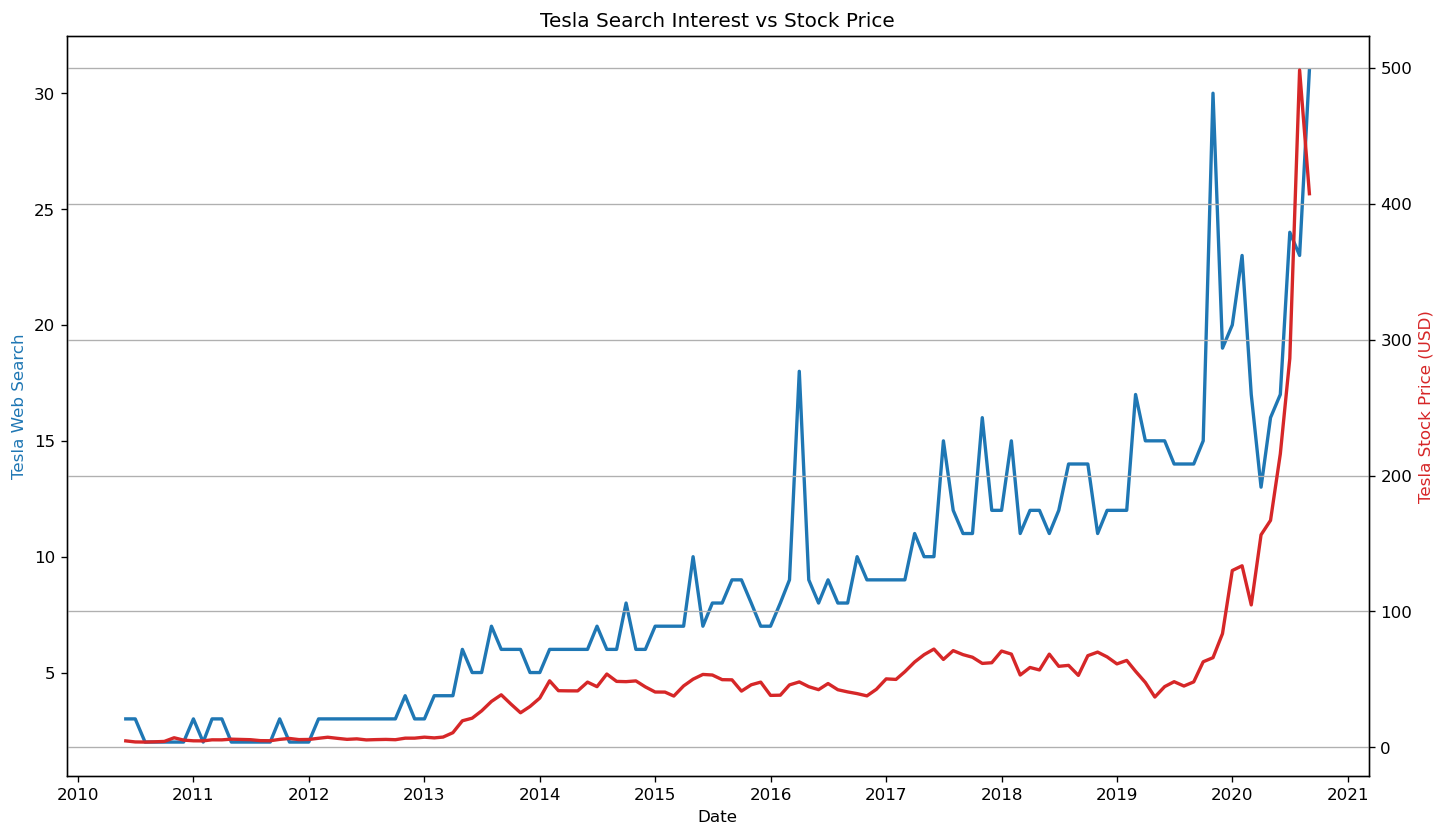

In [19]:
plt.figure(figsize=(14,8), dpi=120)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(df_tesla['MONTH'], df_tesla['TSLA_WEB_SEARCH'],
         color='tab:blue', linewidth=2)

ax2.plot(df_tesla['MONTH'], df_tesla['TSLA_USD_CLOSE'],
         color='tab:red', linewidth=2)

ax1.set_xlabel('Date')
ax1.set_ylabel('Tesla Web Search', color='tab:blue')
ax2.set_ylabel('Tesla Stock Price (USD)', color='tab:red')

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title('Tesla Search Interest vs Stock Price')
plt.grid(True)
plt.show()

**Insight**

Notice how major spikes in Tesla searches often align with strong price movements.

When people start searching like crazy, something interesting is usually happening.

## 🪙 Bitcoin: Search vs Price
### Plot Bitcoin Search vs Monthly Price

### Notebook Formatting & Style Helpers

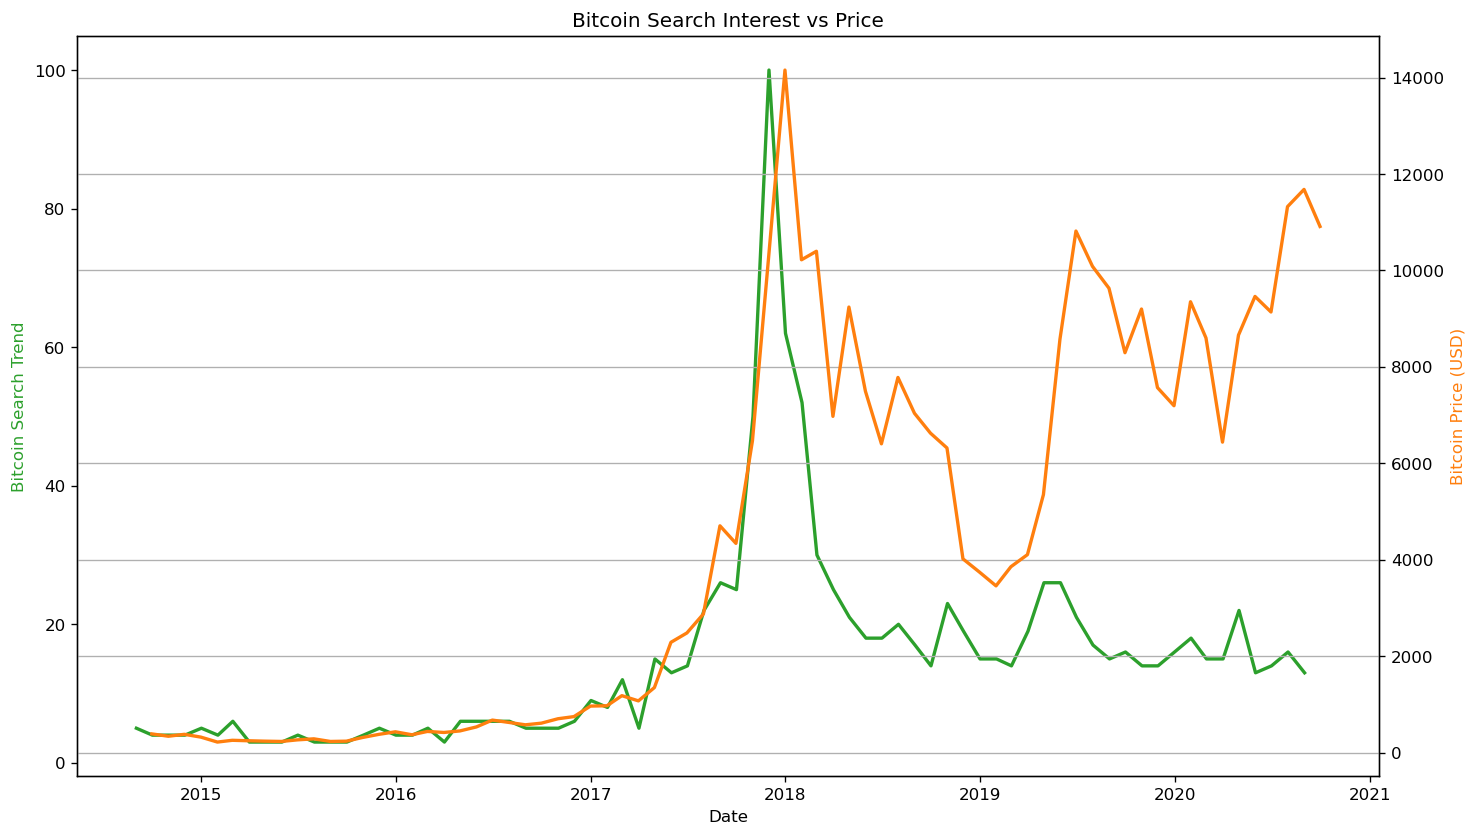

In [20]:
plt.figure(figsize=(14,8), dpi=120)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(df_btc_search['MONTH'], df_btc_search['BTC_NEWS_SEARCH'],
         color='tab:green', linewidth=2)

ax2.plot(monthly_btc.index, monthly_btc['CLOSE'],
         color='tab:orange', linewidth=2)

ax1.set_xlabel('Date')
ax1.set_ylabel('Bitcoin Search Trend', color='tab:green')
ax2.set_ylabel('Bitcoin Price (USD)', color='tab:orange')

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title('Bitcoin Search Interest vs Price')
plt.grid(True)
plt.show()

**Insight**

Search spikes often happen near price peaks.

It’s almost like when everyone starts Googling “Bitcoin”… the party might already be near its climax.

## 📉 Unemployment Benefits vs Unemployment Rate
### Plot Data

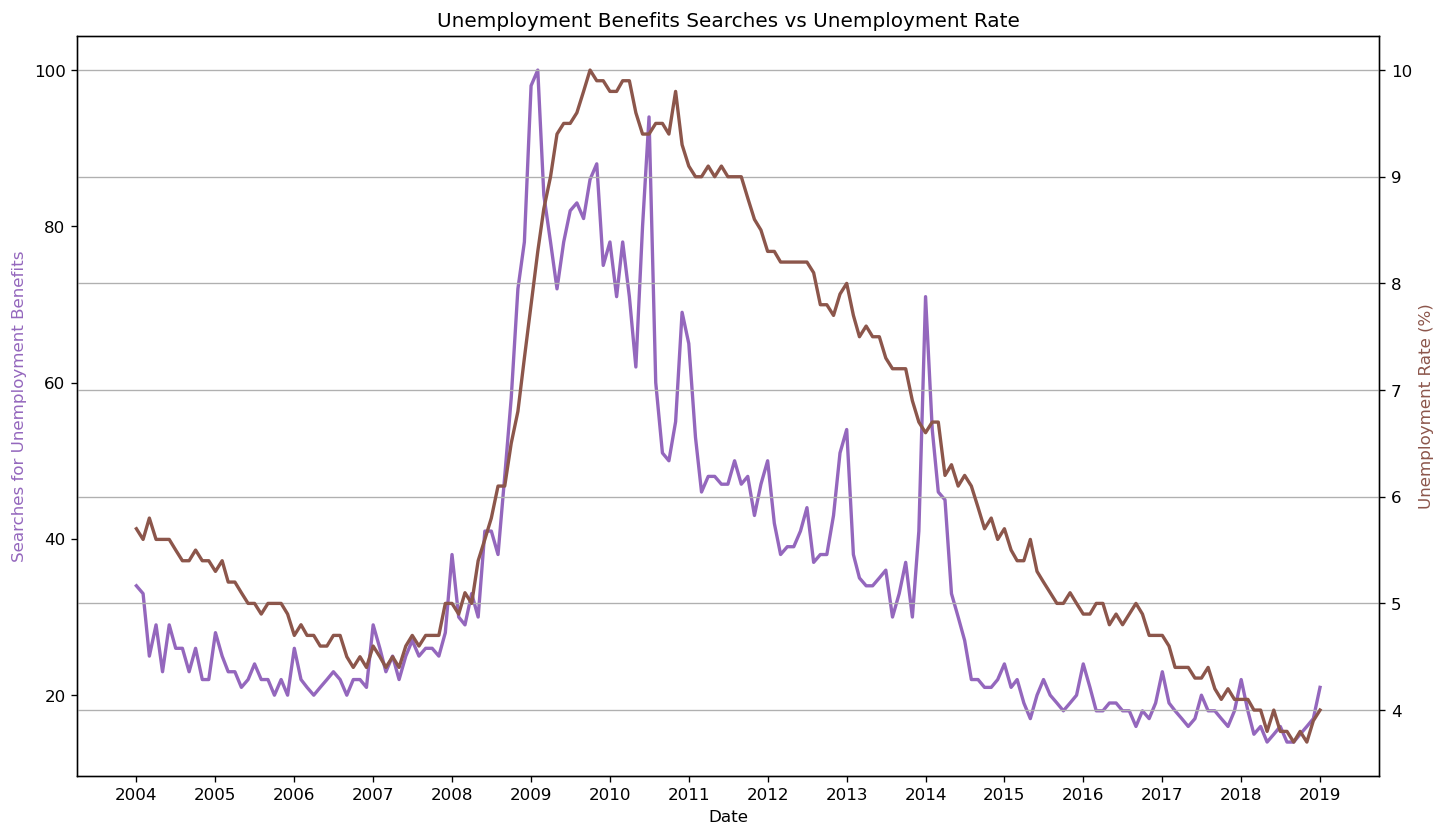

In [21]:
plt.figure(figsize=(14,8), dpi=120)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(df_unemployment['MONTH'],
         df_unemployment['UE_BENEFITS_WEB_SEARCH'],
         color='tab:purple', linewidth=2)

ax2.plot(df_unemployment['MONTH'],
         df_unemployment['UNRATE'],
         color='tab:brown', linewidth=2)

ax1.set_xlabel('Date')
ax1.set_ylabel('Searches for Unemployment Benefits', color='tab:purple')
ax2.set_ylabel('Unemployment Rate (%)', color='tab:brown')

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title('Unemployment Benefits Searches vs Unemployment Rate')
plt.grid(True)
plt.show()

**Insight**

Here the relationship feels more direct.

When unemployment rises, searches for benefits also increase — almost immediately.

Search behavior reflects real human stress in real time.

## 🧠 Final Thoughts

This project shows that search data is more than curiosity — it’s behavioral data.

- Financial bubbles show up in search spikes.
- Stock volatility attracts attention.
- Economic stress drives urgent queries.

Search trends act like a digital heartbeat of society.

> And if we listen carefully, they tell us a lot.